# WiDS 2026 | Multi-Seed Survival Boosting

GBSA ensemble (5 configs x 10 seeds) + LightGBM per-horizon classifiers. 72h sigmoid override.
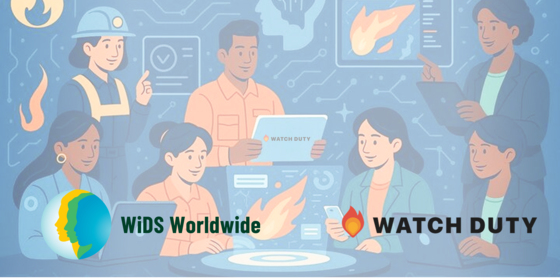

In [1]:
!pip install -q scikit-survival

import numpy as np
import pandas as pd
import warnings
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.util import Surv

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH = Path('/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26')
if not DATA_PATH.exists():
    DATA_PATH = Path('.')

HORIZONS_PRED = np.array([12, 24, 48, 72], dtype=float)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 10.2 MB/s eta 0:00:00


In [2]:
train_df = pd.read_csv(DATA_PATH / 'train.csv')
test_df = pd.read_csv(DATA_PATH / 'test.csv')

print(f'Training: {len(train_df)} samples, Test: {len(test_df)} samples, Features: {train_df.shape[1] - 3}')
print(f'Events: {train_df["event"].sum()} ({train_df["event"].mean():.1%}), Censored: {(1-train_df["event"]).sum():.0f}')

# Key data insight: perfect distance separation
events = train_df[train_df['event'] == 1]
censored = train_df[train_df['event'] == 0]
print(f'\nMax event distance: {events["dist_min_ci_0_5h"].max()/1000:.2f} km')
print(f'Min censored distance: {censored["dist_min_ci_0_5h"].min()/1000:.2f} km')
print(f'Gap: {(censored["dist_min_ci_0_5h"].min() - events["dist_min_ci_0_5h"].max())/1000:.2f} km — PERFECT separation')

Training: 221 samples, Test: 95 samples, Features: 34
Events: 69 (31.2%), Censored: 152

Max event distance: 4.67 km
Min censored distance: 5.22 km
Gap: 0.54 km — PERFECT separation


## Feature Engineering
GBSA uses raw features (34). LGB uses engineered features (45+).

In [3]:
def create_features(df):
    """Engineer features for LGB classifiers."""
    result = df.copy()
    dist = result['dist_min_ci_0_5h'].clip(lower=1)
    speed = result['closing_speed_m_per_h']
    perimeters = result['num_perimeters_0_5h']
    area_first = result['area_first_ha']
    
    # Distance transformations (the dominant signal)
    result['log_distance'] = np.log1p(dist)
    result['inv_distance'] = 1 / (dist / 1000 + 0.1)
    result['inv_distance_sq'] = result['inv_distance'] ** 2
    result['sqrt_distance'] = np.sqrt(dist)
    result['dist_km'] = dist / 1000
    result['dist_km_sq'] = (dist / 1000) ** 2
    result['dist_rank'] = dist.rank(pct=True)
    
    # Area-to-distance features
    fire_radius = np.sqrt(area_first * 10000 / np.pi)
    result['radius_to_dist'] = fire_radius / dist
    result['area_to_dist_ratio'] = area_first / (dist / 1000 + 0.1)
    result['log_area_dist_ratio'] = np.log1p(area_first) - np.log1p(dist)
    
    # Movement / kinematic features
    result['has_movement'] = (perimeters > 1).astype(float)
    closing_pos = speed.clip(lower=0)
    result['eta_hours'] = np.where(closing_pos > 0.01, dist / closing_pos, 9999).clip(max=9999)
    result['log_eta'] = np.log1p(result['eta_hours'].clip(0, 9999))
    radial_growth = result['radial_growth_rate_m_per_h'].clip(lower=0)
    effective_closing = closing_pos + radial_growth
    result['effective_closing_speed'] = effective_closing
    result['eta_effective'] = np.where(effective_closing > 0.01, dist / effective_closing, 9999).clip(max=9999)
    result['threat_score'] = result['alignment_abs'] * speed / np.log1p(dist)
    result['fire_urgency'] = perimeters * speed
    result['growth_intensity'] = result['area_growth_rate_ha_per_h'] * perimeters
    
    # Zone indicators
    result['zone_critical'] = (dist < 5000).astype(float)
    result['zone_warning'] = ((dist >= 5000) & (dist < 10000)).astype(float)
    result['zone_safe'] = (dist >= 10000).astype(float)
    
    # Temporal
    result['is_summer'] = result['event_start_month'].isin([6, 7, 8]).astype(float)
    result['is_afternoon'] = ((result['event_start_hour'] >= 12) & (result['event_start_hour'] < 20)).astype(float)
    
    # Drop redundant features (r > 0.99)
    drop_cols = ['relative_growth_0_5h', 'projected_advance_m', 'centroid_displacement_m',
                 'centroid_speed_m_per_h', 'closing_speed_abs_m_per_h', 'area_growth_abs_0_5h']
    result = result.drop(columns=[c for c in drop_cols if c in result.columns])
    result = result.replace([np.inf, -np.inf], np.nan).fillna(0)
    return result

train_processed = create_features(train_df)
test_processed = create_features(test_df)
print(f'Raw features (GBSA): {train_df.shape[1] - 3}')
print(f'Engineered features (LGB): {len([c for c in train_processed.columns if c not in ["event_id","event","time_to_hit_hours"]])}')

Raw features (GBSA): 34
Engineered features (LGB): 51


In [4]:
# === Evaluation Metrics ===
# Hybrid = 0.3 * C-index + 0.7 * (1 - Weighted_Brier)
# Weighted_Brier = 0.3 * B@24 + 0.4 * B@48 + 0.3 * B@72

def compute_c_index(time, event, risk):
    n = len(time)
    concordant = comparable = 0
    for i in range(n):
        if event[i] != 1: continue
        for j in range(n):
            if i == j or time[i] >= time[j]: continue
            comparable += 1
            if risk[i] > risk[j]: concordant += 1
            elif risk[i] == risk[j]: concordant += 0.5
    return concordant / comparable if comparable > 0 else 0.5

def compute_brier(time, event, prob, horizon):
    valid = ~((event == 0) & (time < horizon))
    if valid.sum() == 0: return 0.25
    y_true = ((event == 1) & (time <= horizon)).astype(float)[valid]
    return float(np.mean((np.clip(prob[valid], 0, 1) - y_true) ** 2))

def compute_hybrid_score(time, event, p24, p48, p72):
    risk = 0.3 * p24 + 0.4 * p48 + 0.3 * p72
    c_index = compute_c_index(time, event, risk)
    b24 = compute_brier(time, event, p24, 24)
    b48 = compute_brier(time, event, p48, 48)
    b72 = compute_brier(time, event, p72, 72)
    wb = 0.3 * b24 + 0.4 * b48 + 0.3 * b72
    return 0.3 * c_index + 0.7 * (1 - wb), c_index, wb

def enforce_monotonicity(preds):
    result = np.clip(preds, 0, 1)
    for i in range(1, result.shape[1]):
        result[:, i] = np.maximum(result[:, i], result[:, i-1])
    return result

def get_surv_predictions(model, X):
    surv_fns = model.predict_survival_function(X)
    preds = np.empty((len(surv_fns), len(HORIZONS_PRED)), dtype=float)
    for i, fn in enumerate(surv_fns):
        t_min, t_max = fn.domain
        preds[i, :] = fn(np.clip(HORIZONS_PRED, t_min, t_max))
    return 1.0 - preds

def sigmoid_pred(dist, threshold, scale):
    return 1.0 / (1.0 + np.exp((dist - threshold) / scale))

def make_binary_target(time_vals, event_vals, horizon):
    unknown = (event_vals == 0) & (time_vals < horizon)
    y = ((event_vals == 1) & (time_vals <= horizon)).astype(float)
    return y, ~unknown

def compute_ipcw_weights(times, events, horizon):
    """Compute IPCW weights from Kaplan-Meier censoring distribution.
    Properly accounts for censoring bias in per-horizon classifiers.
    G(t) = P(not censored by time t), estimated by KM on censoring times.
    """
    unique_t = np.sort(np.unique(times))
    surv = np.ones(len(unique_t))
    for i, t in enumerate(unique_t):
        at_risk = (times >= t).sum()
        censored_at_t = ((times == t) & (events == 0)).sum()
        if at_risk > 0:
            surv[i] = 1 - censored_at_t / at_risk
        if i > 0:
            surv[i] *= surv[i - 1]

    def G(t):
        idx = np.searchsorted(unique_t, t, side='right') - 1
        return max(surv[idx], 0.01) if idx >= 0 else 1.0

    weights = np.ones(len(times))
    for i in range(len(times)):
        if events[i] == 1 and times[i] <= horizon:
            weights[i] = 1.0 / G(times[i])
        elif times[i] >= horizon:
            weights[i] = 1.0 / G(horizon)
    return weights

## GBSA Ensemble (5 configs x 10 seeds = 50 models)

In [5]:
X_surv_train = train_df.drop(columns=['event_id', 'event', 'time_to_hit_hours'])
X_surv_test = test_df.drop(columns=['event_id'])
y_surv = Surv.from_arrays(event=train_df['event'].astype(bool), time=train_df['time_to_hit_hours'])
time_values = train_df['time_to_hit_hours'].values
event_values = train_df['event'].values
dist_train = train_df['dist_min_ci_0_5h'].values
dist_test = test_df['dist_min_ci_0_5h'].values

# Configs selected from systematic hyperparameter search
gbsa_configs = [
    {'learning_rate': 0.01, 'subsample': 0.7,  'max_depth': 3, 'min_samples_leaf': 12, 'min_samples_split': 3, 'n_estimators': 1200, 'dropout_rate': 0.0},
    {'learning_rate': 0.01, 'subsample': 0.85, 'max_depth': 3, 'min_samples_leaf': 15, 'min_samples_split': 3, 'n_estimators': 1200, 'dropout_rate': 0.0},
    {'learning_rate': 0.01, 'subsample': 0.6,  'max_depth': 3, 'min_samples_leaf': 12, 'min_samples_split': 3, 'n_estimators': 1200, 'dropout_rate': 0.0},
    {'learning_rate': 0.005, 'subsample': 0.85, 'max_depth': 3, 'min_samples_leaf': 12, 'min_samples_split': 3, 'n_estimators': 2000, 'dropout_rate': 0.0},
    {'learning_rate': 0.01, 'subsample': 0.85, 'max_depth': 3, 'min_samples_leaf': 20, 'min_samples_split': 3, 'n_estimators': 1400, 'dropout_rate': 0.0},
]
N_SEEDS = 10

oof_gbsa = np.zeros((len(X_surv_train), 4))
test_gbsa = np.zeros((len(X_surv_test), 4))

for cfg_idx, cfg in enumerate(gbsa_configs):
    cfg_oof = np.zeros((len(X_surv_train), 4))
    cfg_test = np.zeros((len(X_surv_test), 4))
    for seed in range(42, 42 + N_SEEDS):
        seed_oof = np.zeros((len(X_surv_train), 4))
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr_idx, va_idx in cv.split(X_surv_train, event_values):
            m = GradientBoostingSurvivalAnalysis(**{**cfg, 'random_state': seed})
            m.fit(X_surv_train.iloc[tr_idx], y_surv[tr_idx])
            seed_oof[va_idx] = get_surv_predictions(m, X_surv_train.iloc[va_idx])
        cfg_oof += seed_oof / N_SEEDS
        # Full-data model for test predictions
        m_full = GradientBoostingSurvivalAnalysis(**{**cfg, 'random_state': seed})
        m_full.fit(X_surv_train, y_surv)
        cfg_test += get_surv_predictions(m_full, X_surv_test) / N_SEEDS
    oof_gbsa += cfg_oof / len(gbsa_configs)
    test_gbsa += cfg_test / len(gbsa_configs)
    print(f'Config {cfg_idx+1}/{len(gbsa_configs)} done (n={cfg["n_estimators"]}, ss={cfg["subsample"]}, msl={cfg["min_samples_leaf"]})')

print(f'\nGBSA: {len(gbsa_configs)} configs x {N_SEEDS} seeds = {len(gbsa_configs)*N_SEEDS} models')
print('Test predictions: full-data model (all 221 samples, averaged across seeds)')

Config 1/5 done (n=1200, ss=0.7, msl=12)
Config 2/5 done (n=1200, ss=0.85, msl=15)
Config 3/5 done (n=1200, ss=0.6, msl=12)
Config 4/5 done (n=2000, ss=0.85, msl=12)
Config 5/5 done (n=1400, ss=0.85, msl=20)

GBSA: 5 configs x 10 seeds = 50 models
Test predictions: full-data model (all 221 samples, averaged across seeds)


## LightGBM Per-Horizon Classifiers (24h, 48h) with IPCW

In [6]:
X_lgb_train = train_processed.drop(columns=['event_id', 'event', 'time_to_hit_hours'])
X_lgb_test = test_processed.drop(columns=['event_id'])

lgb_cfgs = {
    24: {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 300,
         'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_samples': 8,
         'reg_alpha': 0.5, 'reg_lambda': 2.0, 'num_leaves': 7},
    48: {'max_depth': 2, 'learning_rate': 0.05, 'n_estimators': 200,
         'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 5,
         'reg_alpha': 0.1, 'reg_lambda': 1.0, 'num_leaves': 4},
}
N_LGB_SEEDS = 20
lgb_oof, lgb_test = {}, {}

for horizon in [24, 48]:
    y_bin, mask = make_binary_target(time_values, event_values, horizon)
    valid_idx = np.where(mask)[0]
    cfg = lgb_cfgs[horizon]
    all_oof = np.zeros(len(X_lgb_train))
    all_test = np.zeros(len(X_lgb_test))
    for seed in range(42, 42 + N_LGB_SEEDS):
        seed_oof = np.zeros(len(X_lgb_train))
        last_model = None
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr_v, va_v in cv.split(valid_idx, y_bin[mask]):
            tr_idx, va_idx = valid_idx[tr_v], valid_idx[va_v]
            ipcw_w = compute_ipcw_weights(
                time_values[tr_idx], event_values[tr_idx], horizon)
            m = lgb.LGBMClassifier(**cfg, objective='binary', random_state=seed, verbose=-1)
            m.fit(X_lgb_train.iloc[tr_idx], y_bin[tr_idx], sample_weight=ipcw_w)
            seed_oof[va_idx] = m.predict_proba(X_lgb_train.iloc[va_idx])[:, 1]
            last_model = m
        # Fill censored OOF using last fold model (only for OOF display, excluded from Brier)
        censored_idx = np.where(~mask)[0]
        if len(censored_idx) > 0 and last_model is not None:
            seed_oof[censored_idx] = last_model.predict_proba(X_lgb_train.iloc[censored_idx])[:, 1]
        all_oof += seed_oof
        # Full-data model for test predictions
        ipcw_w_full = compute_ipcw_weights(time_values[valid_idx], event_values[valid_idx], horizon)
        m_full = lgb.LGBMClassifier(**cfg, objective='binary', random_state=seed, verbose=-1)
        m_full.fit(X_lgb_train.iloc[valid_idx], y_bin[valid_idx], sample_weight=ipcw_w_full)
        all_test += m_full.predict_proba(X_lgb_test)[:, 1]
    lgb_oof[horizon] = all_oof / N_LGB_SEEDS
    lgb_test[horizon] = all_test / N_LGB_SEEDS
    b = compute_brier(time_values, event_values, np.clip(lgb_oof[horizon], 0, 1), horizon)
    print(f'LGB {horizon}h (IPCW): B@{horizon}={b:.5f} ({N_LGB_SEEDS} seeds)')

LGB 24h (IPCW): B@24=0.02546 (20 seeds)
LGB 48h (IPCW): B@48=0.01300 (20 seeds)


## Blend & Submit

In [7]:
W_GBSA_24 = 0.95
W_GBSA_48 = 0.55

# Blend OOF
oof_blend = oof_gbsa.copy()
oof_blend[:, 1] = W_GBSA_24 * oof_gbsa[:, 1] + (1 - W_GBSA_24) * lgb_oof[24]
oof_blend[:, 2] = W_GBSA_48 * oof_gbsa[:, 2] + (1 - W_GBSA_48) * lgb_oof[48]
oof_blend[:, 3] = sigmoid_pred(dist_train, 5450, 50)

# Blend test
test_blend = test_gbsa.copy()
test_blend[:, 1] = W_GBSA_24 * test_gbsa[:, 1] + (1 - W_GBSA_24) * lgb_test[24]
test_blend[:, 2] = W_GBSA_48 * test_gbsa[:, 2] + (1 - W_GBSA_48) * lgb_test[48]
test_blend[:, 3] = sigmoid_pred(dist_test, 5450, 50)

# Enforce monotonicity
oof_final = enforce_monotonicity(oof_blend)
test_final = enforce_monotonicity(test_blend)

# Evaluate OOF
hybrid, c_idx, wb = compute_hybrid_score(time_values, event_values,
                                          oof_final[:, 1], oof_final[:, 2], oof_final[:, 3])
b24 = compute_brier(time_values, event_values, oof_final[:, 1], 24)
b48 = compute_brier(time_values, event_values, oof_final[:, 2], 48)
b72 = compute_brier(time_values, event_values, oof_final[:, 3], 72)

print(f'OOF Hybrid Score: {hybrid:.5f}')
print(f'  C-Index:        {c_idx:.4f}')
print(f'  Weighted Brier: {wb:.5f}')
print(f'    B@24: {b24:.5f}  B@48: {b48:.5f}  B@72: {b72:.5f}')
print(f'\nBlend: 24h={W_GBSA_24:.0%} GBSA, 48h={W_GBSA_48:.0%} GBSA, 72h=sigmoid')

OOF Hybrid Score: 0.97491
  C-Index:        0.9467
  Weighted Brier: 0.01299
    B@24: 0.02654  B@48: 0.01257  B@72: 0.00000

Blend: 24h=95% GBSA, 48h=55% GBSA, 72h=sigmoid


In [8]:
submission = pd.DataFrame({
    'event_id': test_df['event_id'],
    'prob_12h': test_final[:, 0],
    'prob_24h': test_final[:, 1],
    'prob_48h': test_final[:, 2],
    'prob_72h': test_final[:, 3],
})

# Validation checks
assert len(submission) == len(test_df)
assert submission[['prob_12h','prob_24h','prob_48h','prob_72h']].notna().all().all()
for a, b in [('prob_12h','prob_24h'), ('prob_24h','prob_48h'), ('prob_48h','prob_72h')]:
    assert (submission[b] >= submission[a] - 1e-9).all(), f'Monotonicity: {a} > {b}'

submission.to_csv('submission.csv', index=False)
print('Saved: submission.csv')
print(submission.describe().round(4))

Saved: submission.csv
           event_id  prob_12h  prob_24h  prob_48h  prob_72h
count  9.500000e+01   95.0000   95.0000   95.0000   95.0000
mean   5.695393e+07    0.2044    0.2855    0.3051    0.3195
std    2.329721e+07    0.3184    0.3949    0.4211    0.4423
min    1.066260e+07    0.0109    0.0263    0.0263    0.0263
25%    4.027536e+07    0.0140    0.0337    0.0337    0.0337
50%    5.480111e+07    0.0150    0.0361    0.0361    0.0361
75%    7.536942e+07    0.4136    0.7487    0.8743    1.0000
max    9.964946e+07    0.9999    0.9999    0.9999    1.0000
